In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc, copy
import numpy as np
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
          'axes.labelsize': 'large',
          'axes.titlesize': 'large',
          'xtick.labelsize': 'large',
          'ytick.labelsize': 'large',
          'figure.facecolor': 'w',
          'xtick.top': True,
          'ytick.right': True,
          'xtick.direction': 'in',
          'ytick.direction': 'in',
         }
plt.rcParams.update(params)

In [3]:
# perexp = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_perexp_lrg.fits'))
perexp = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_perexp_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = perexp['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove "no data" fibers
mask = perexp['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Apply LRG mask
mask = perexp['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove QSO targets
mask = perexp['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove objects classified as QSOs
mask = perexp['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove objects classified as STARs
mask = perexp['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# mask = perexp['main_lrg'].copy()
# print('Main LRG', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# perexp = perexp[mask]

# Redshift quality cut
perexp['q'] = perexp['ZWARN']==0
perexp['q'] &= (perexp['Z']<1.5)
perexp['q'] &= perexp['DELTACHI2']>15
print(np.sum(~perexp['q'])/len(perexp))

perexp['main_survey'] = False
perexp['zfibermag'] = 22.5 - 2.5*np.log10(perexp['FIBERFLUX_Z']) - 1.211 * perexp['EBV']

FIBERSTATUS 464751 107007 0.18715435551404616
No data 464751 0 0.0
LRG mask 417693 47058 0.10125422000167832
Remove QSO targets 403772 13921 0.03332830571735701
Remove objects classified as QSOs: 398156 5616 0.013908839642174296
Remove objects classified as STARs: 395487 2669 0.006703402686384231
0.3363245820975152


In [4]:
# cat_1x = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_1x_depth_lrg.fits'))
cat_1x = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_1x_depth_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = cat_1x['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove "no data" fibers
mask = cat_1x['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Apply LRG mask
mask = cat_1x['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove QSO targets
mask = cat_1x['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove objects classified as QSOs
mask = cat_1x['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove objects classified as STARs
mask = cat_1x['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# mask = cat_1x['main_lrg'].copy()
# print('Main LRG', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat_1x = cat_1x[mask]

# Redshift quality cut
cat_1x['q'] = cat_1x['ZWARN']==0
cat_1x['q'] &= (cat_1x['Z']<1.5)
cat_1x['q'] &= cat_1x['DELTACHI2']>15
print(np.sum(~cat_1x['q'])/len(cat_1x))

cat_1x['main_survey'] = False
cat_1x['zfibermag'] = 22.5 - 2.5*np.log10(cat_1x['FIBERFLUX_Z']) - 1.211 * cat_1x['EBV']

FIBERSTATUS 27110 4943 0.15421333416528873
No data 27110 0 0.0
LRG mask 25008 2102 0.07753596458871265
Remove QSO targets 24493 515 0.020593410108765194
Remove objects classified as QSOs: 24169 324 0.013228269301433063
Remove objects classified as STARs: 24013 156 0.0064545492159377715
0.08128930162828468


In [5]:
# deep = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_cumulative_lrg.fits'))
deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove objects classified as QSOs
mask = deep['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove objects classified as STARs
mask = deep['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# mask = deep['main_lrg'].copy()
# print('Main LRG', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# deep = deep[mask]

# Redshift quality cut
deep['q'] = deep['ZWARN']==0
deep['q'] &= (deep['Z']<1.5)
deep['q'] &= deep['DELTACHI2']>15
print(np.sum(~deep['q'])/len(deep))

deep['main_survey'] = False
deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']) - 1.211 * deep['EBV']

COADD_FIBERSTATUS 46319 8916 0.16141938987960533
No data 45437 882 0.01904186187093849
LRG mask 41340 4097 0.09016880515879129
Remove QSO targets 39668 1672 0.040445089501693274
Remove objects classified as QSOs: 39299 369 0.009302208329131794
Remove objects classified as STARs: 38993 306 0.007786457670678643
0.009078552560716026


In [6]:
# main = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_lrg.fits'))
main = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/main_cumulative_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = main['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove "no data" fibers
mask = main['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Apply LRG mask
mask = main['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove QSO targets
mask = main['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove objects classified as QSOs
mask = main['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove objects classified as STARs
mask = main['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Redshift quality cut
main['q'] = main['ZWARN']==0
main['q'] &= (main['Z']<1.5)
main['q'] &= main['DELTACHI2']>15
print(np.sum(~main['q'])/len(main))

main['main_survey'] = True
main['zfibermag'] = 22.5 - 2.5*np.log10(main['FIBERFLUX_Z']) - 1.211 * main['EBV']

FIBERSTATUS 338266 7165 0.020742203218587794
No data 338265 1 2.9562533627382e-06
LRG mask 304337 33928 0.1003000606033731
Remove QSO targets 299639 4698 0.015436834824553046
Remove objects classified as QSOs: 296052 3587 0.011971071856467282
Remove objects classified as STARs: 294641 1411 0.0047660546120276166
0.012065530594859507


In [7]:
# sv3 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv3_cumulative_lrg.fits'))
sv3 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv3_cumulative_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = sv3['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
sv3 = sv3[mask]

# Remove "no data" fibers
mask = sv3['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
sv3 = sv3[mask]

# Apply LRG mask
mask = sv3['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
sv3 = sv3[mask]

# Remove QSO targets
mask = sv3['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
sv3 = sv3[mask]

# Remove objects classified as QSOs
mask = sv3['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
sv3 = sv3[mask]

# Remove objects classified as STARs
mask = sv3['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
sv3 = sv3[mask]

# Redshift quality cut
sv3['q'] = sv3['ZWARN']==0
sv3['q'] &= (sv3['Z']<1.5)
sv3['q'] &= sv3['DELTACHI2']>15
print(np.sum(~sv3['q'])/len(sv3))

sv3['main_survey'] = False
sv3['zfibermag'] = 22.5 - 2.5*np.log10(sv3['FIBERFLUX_Z']) - 1.211 * sv3['EBV']

FIBERSTATUS 164618 18004 0.09858615062807329
No data 164614 4 2.4298679366776417e-05
LRG mask 150726 13888 0.08436706476970367
Remove QSO targets 150726 0 0.0
Remove objects classified as QSOs: 148547 2179 0.014456696256783834
Remove objects classified as STARs: 148209 338 0.0022753741240146216
0.014951858524111222


In [8]:
mask_main = np.full(len(main), True)
mask_perexp = perexp['main_lrg'].copy() | (perexp['zfibermag']>21.6)
mask_1x = cat_1x['main_lrg'].copy() | (cat_1x['zfibermag']>21.6)
mask_deep = deep['main_lrg'].copy() | (deep['zfibermag']>21.6)
mask_sv3 = np.full(len(sv3), True)
cat = vstack([main[mask_main], perexp[mask_perexp], cat_1x[mask_1x], deep[mask_deep], sv3[mask_sv3]], join_type='inner')
# lrg1 = vstack([cat, main], join_type='inner')

In [9]:
def failure_rate(flux, efftime, a0, a1, a2):
    sn = flux * np.sqrt(efftime)
    return np.clip(np.exp(a0*sn+a1)+a2/flux, 0, 1)

coeffs = [-0.0911, 3.34, 0.0228]  # Main+SV3
# coeffs = [-3.17895290e+01,  1.38433346e+01,  5.20481764e-03]  # All LRGs

a0, a1, a2 = -1/coeffs[1], -coeffs[0]/coeffs[1], coeffs[2]
print(a0, a1, a2)

-0.29940119760479045 0.02727544910179641 0.0228


In [10]:
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']
cat['FIBERFLUX_Z_EC'] = cat['FIBERFLUX_Z']*10**(0.4*1.211*cat['EBV'])
cat['fail_prob'] = failure_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)

min_count = 1

/var/folders/p9/q1f79whn6670tx6f2ngp9t140000gn/T/ipykernel_32878/2104915960.py:7: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all
/var/folders/p9/q1f79whn6670tx6f2ngp9t140000gn/T/ipykernel_32878/2104915960.py:9: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all


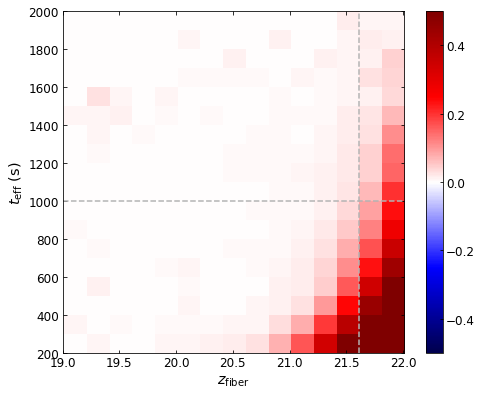

/var/folders/p9/q1f79whn6670tx6f2ngp9t140000gn/T/ipykernel_32878/2104915960.py:31: RuntimeWarning: invalid value encountered in true_divide
  success_2d_predict = count_2d_good_predict/count_2d_all


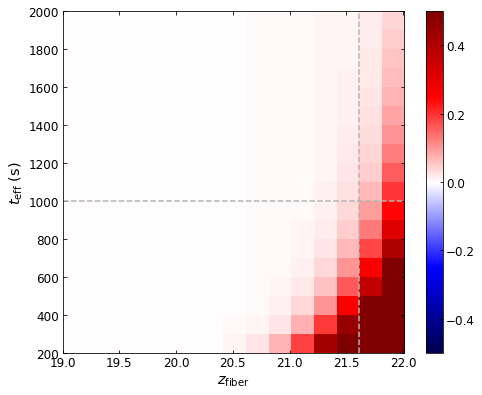

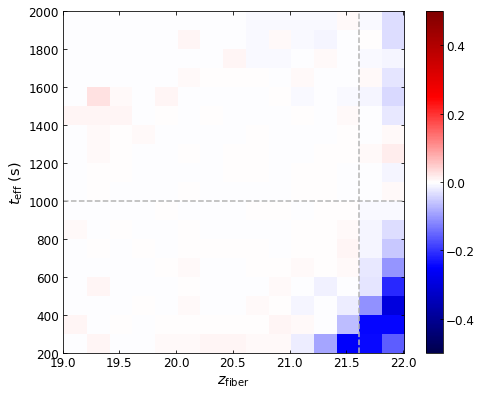

In [11]:
zfiber_bin_edges = np.linspace(18.01, 22.01, 21)
efftime_bin_edges = np.linspace(100, 2000, 20)

count_2d_all = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = (~cat['q']).copy()
count_2d_good = np.histogram2d(cat['zfibermag'][mask], cat['EFFTIME_LRG'][mask], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
success_2d = count_2d_good/count_2d_all

success_2d = count_2d_good/count_2d_all
success_2d[count_2d_all<=min_count] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
current_cmap = copy.copy(matplotlib.cm.get_cmap("seismic"))
current_cmap.set_bad(color='0.8')
cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=-0.5, vmax=0.5, cmap=current_cmap,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_ylabel('$t_\mathrm{eff}$ (s)', fontsize='x-large')
ax.set_xlim(xmin=19)
ax.set_ylim(200)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/failure_rate_in_2d.pdf')
plt.show()

###############################################################################################

count_2d_good_predict = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges], weights=cat['fail_prob'])[0]
success_2d_predict = count_2d_good_predict/count_2d_all

success_2d_predict[count_2d_all<=min_count] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
current_cmap = copy.copy(matplotlib.cm.get_cmap("seismic"))
current_cmap.set_bad(color='0.8')
cax = ax.imshow(success_2d_predict.T, origin='lower', aspect='auto', vmin=-0.5, vmax=0.5, cmap=current_cmap,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_ylabel('$t_\mathrm{eff}$ (s)', fontsize='x-large')
ax.set_xlim(xmin=19)
ax.set_ylim(200)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/failure_rate_in_2d.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(7, 5.6))
current_cmap = copy.copy(matplotlib.cm.get_cmap("seismic"))
current_cmap.set_bad(color='0.8')
cax = ax.imshow((success_2d-success_2d_predict).T, origin='lower', aspect='auto', vmin=-0.5, vmax=0.5, cmap=current_cmap,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_ylabel('$t_\mathrm{eff}$ (s)', fontsize='x-large')
ax.set_xlim(xmin=19)
ax.set_ylim(200)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/failure_rate_in_2d.pdf')
plt.show()

/var/folders/p9/q1f79whn6670tx6f2ngp9t140000gn/T/ipykernel_32878/3695783621.py:18: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all
/var/folders/p9/q1f79whn6670tx6f2ngp9t140000gn/T/ipykernel_32878/3695783621.py:20: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all
/var/folders/p9/q1f79whn6670tx6f2ngp9t140000gn/T/ipykernel_32878/3695783621.py:40: RuntimeWarning: invalid value encountered in true_divide
  success_2d_predict = count_2d_good_predict/count_2d_all


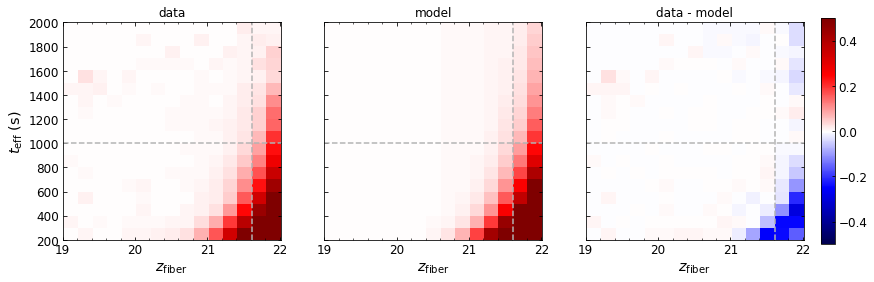

In [12]:
fits = fitsio.FITS('zenodo/fig_13.fits','rw')

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# current_cmap = copy.copy(matplotlib.cm.get_cmap("seismic"))
# current_cmap.set_bad(color='0.8')

###############################################################################################

ax = axes[0]

zfiber_bin_edges = np.linspace(18.01, 22.01, 21)
efftime_bin_edges = np.linspace(100, 2000, 20)

count_2d_all = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = (~cat['q']).copy()
count_2d_good = np.histogram2d(cat['zfibermag'][mask], cat['EFFTIME_LRG'][mask], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
success_2d = count_2d_good/count_2d_all

success_2d = count_2d_good/count_2d_all
success_2d[count_2d_all<=min_count] = np.nan

hdict = {'axis0': 'zfibermag', 'axis1': 'efftime'}
fits.write(success_2d, extname='data', header=hdict)

cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=-0.5, vmax=0.5, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_ylabel('$t_\mathrm{eff}$ (s)', fontsize='x-large')
ax.set_xlim(xmin=19)
ax.set_ylim(200)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
ax.set_title('data')
ax.xaxis.set_minor_locator(AutoMinorLocator())

ax = axes[1]

count_2d_good_predict = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges], weights=cat['fail_prob'])[0]
success_2d_predict = count_2d_good_predict/count_2d_all

success_2d_predict[count_2d_all<=min_count] = np.nan

hdict = {'axis0': 'zfibermag', 'axis1': 'efftime'}
fits.write(success_2d, extname='model', header=hdict)

cax = ax.imshow(success_2d_predict.T, origin='lower', aspect='auto', vmin=-0.5, vmax=0.5, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_xlim(xmin=19)
ax.set_ylim(200)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
ax.set_title('model')
ax.xaxis.set_minor_locator(AutoMinorLocator())

ax = axes[2]

hdict = {'axis0': 'zfibermag', 'axis1': 'efftime'}
fits.write(success_2d-success_2d_predict, extname='data-model', header=hdict)

cax = ax.imshow((success_2d-success_2d_predict).T, origin='lower', aspect='auto', vmin=-0.5, vmax=0.5, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$', fontsize='x-large')
ax.set_xlim(xmin=19)
ax.set_ylim(200)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
ax.set_title('data - model')
ax.xaxis.set_minor_locator(AutoMinorLocator())

fig.colorbar(cax, ax=axes, location='right', shrink=1.04, pad=0.02, aspect=17)

# plt.tight_layout()
# plt.gcf().subplots_adjust(bottom=0.15)
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/failure_rate_in_2d.pdf', bbox_inches="tight")
plt.show()

fits.close()

In [13]:
fitsio.FITS('zenodo/fig_13.fits')


  file: zenodo/fig_13.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       data
  1      IMAGE_HDU       model
  2      IMAGE_HDU       data-model